/Users/alex/Library/CloudStorage/OneDrive-UniversityofWyoming/Work/UWyo/Research/PostProc/FluxFox/postproc/ustar.py:230: UserWarning: Warning! I was unable to determine a USTAR threshold for 70% of the study period!
  warnings.warn(f"Warning! I was unable to determine a USTAR threshold for {num_na/ustar_thresh_df.size*100:.0f}% of the study period!")


[xgb_gapfill] 86517 rows total | 56166 target gaps to fill | 22835 rows usable for training | 7516 non-gap rows dropped for excess missing predictors
[xgb_gapfill] hyperparameter search: 2283 train / 754 test rows, 10 Bayes iterations, 3-fold CV scoring
[xgb_gapfill] best hyperparameters: {'l2_regularization': 0.000320284679026617, 'learning_rate': 0.060235147398362554, 'max_depth': 6, 'max_iter': 168, 'max_leaf_nodes': 64, 'min_samples_leaf': 7}
[xgb_gapfill] held-out hyper_test RMSE: 1.0975
[xgb_gapfill] final model test scores: RMSE=0.7914, R2=0.8360, bias=0.0051 (n_test=4567)
[xgb_gapfill] refitting final model on all usable rows


/Users/alex/Library/CloudStorage/OneDrive-UniversityofWyoming/Work/UWyo/Research/PostProc/FluxFox/postproc/gapfill.py:394: UserWarning: [xgb_gapfill] WARNING: 41326 gap rows exceed the n_missing_allowed=1 predictor NaN tolerance and cannot be filled; they remain NaN.
  warnings.warn(msg)


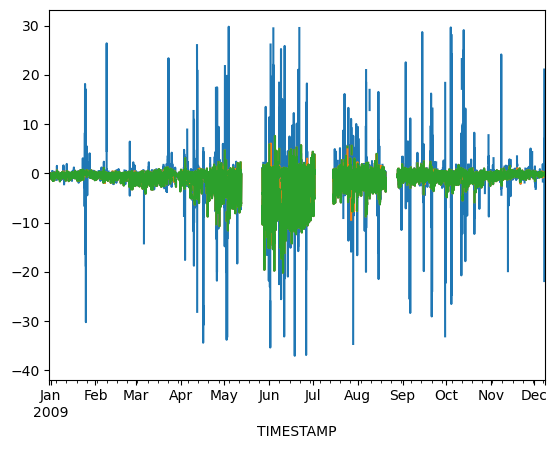

In [ ]:
from dataclasses import dataclass
from typing import Any, Optional
import warnings

import pandas as pd
import numpy as np
from scipy import optimize
from scipy import stats
import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.append("/Users/alex/Library/CloudStorage/OneDrive-UniversityofWyoming/Work/UWyo/Research/PostProc")
from FluxFox import postproc
from FluxFox.postproc.utils import compute_isday

import numpy as np
import pandas as pd

wd = Path("/Users/alex/Library/CloudStorage/OneDrive-UniversityofWyoming/Work/UWyo/Research/PostProc/tests")
    
cpk = pd.read_parquet(wd / "data" / "cpk.parquet")
float_cols = cpk.select_dtypes(include=["float"]).columns
cpk.loc[:, float_cols] = cpk.loc[:, float_cols].astype("float32")
lat, lon, elev = 41.3966, -106.8024, 2069.0

start, end = "2008-12-31", "2009-12-31"
cpk.loc[start:end, "FC"].plot(label="Original FC")

# despike
spike_flag = postproc.mad_despike_papale_2006(cpk, list(cpk), lat, lon, elev, z=4)
cpk = cpk.where(spike_flag)
cpk.loc[start:end, "FC"].plot(label="Despiked FC")

# ustar filter
ustar_flag = postproc.ustar_filter_papale_2006(cpk, "TA", "USTAR", "FC", lat, lon, elev).flag
cpk.loc[~ustar_flag, ["H", "LE", "FC"]] = np.nan
cpk.loc[start:end, "FC"].plot(label="Ustar Filtered FC")

# gapfill
gapfill_result = postproc.xgb_gapfill_liu_2025(
    cpk, "FC",
    ta_col="TA",
    ppfd_col="PPFD_IN",
    vpd_col="VPD_PI",
    tsoil_col="TS_1_1_1",
    swc_col="SWC_1_1_1",
    extra_predictor_cols=["WD"],
    n_missing_allowed=1,
    random_state=8472,
    verbose=True,
    
    hyper_train_frac=0.1,  # 0.3
    hyper_test_frac=0.033,  # 0.1
    n_bayes_iter=10,  #50
    cv_folds=3,  # 5
)
cpk.loc[:, "FC"] = gapfill_result.filled


In [12]:
isday

TIMESTAMP
2008-07-31 00:00:00    False
2008-07-31 00:30:00    False
2008-07-31 01:00:00    False
2008-07-31 01:30:00    False
2008-07-31 02:00:00    False
                       ...  
2008-08-31 21:30:00    False
2008-08-31 22:00:00    False
2008-08-31 22:30:00    False
2008-08-31 23:00:00    False
2008-08-31 23:30:00    False
Name: SW_IN_POT, Length: 1536, dtype: bool

/var/folders/h1/hhwj_15n5pjc0cht5mmph_y40000gn/T/ipykernel_33601/1882259839.py:216: UserWarning: At least one of the optimally chosen E0 values is very small (0.000000). Check data quality and fitting procedure. This is often caused by NEE being biased negative at night.
  warnings.warn(f"At least one of the optimally chosen E0 values is very small ({E0_results['E0'].min():.6f}). Check data quality and fitting procedure. This is often caused by NEE being biased negative at night.")


(-5.0, 2.0)

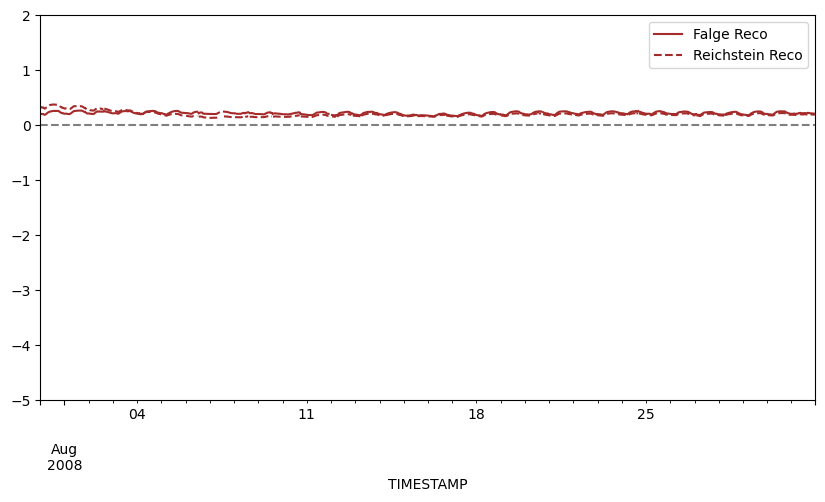

In [77]:
def _lloyd_taylor_1994(T: np.ndarray, R_ref: float, E0: float) -> np.ndarray:
    """
    Lloyd and Taylor (1994) model of ecosystem respiration as a function of temperature.
    """
    T_ref = 10 + 273.15
    T0 = -46.02 + 273.15
    return R_ref * np.exp(E0 * (1. / (T_ref - T0) - 1. / (T - T0 + 273.15)))

def _fit_lt94(x_data: np.ndarray, y_data: np.ndarray, fix_E0: Optional[float] = None) -> Any:
    def objective(p: np.ndarray) -> float:
        if fix_E0 is not None:
            E0 = fix_E0
            R_ref = p
        else:
            R_ref, E0 = p
        y_hat = _lloyd_taylor_1994(x_data, R_ref=R_ref, E0=E0)
        # return np.sum((y_data - y_hat) ** 2)
        return np.sum(np.abs(y_data - y_hat))
    if fix_E0 is not None:
        res = optimize.minimize(
            objective,
            x0=np.array([2.0]), bounds=optimize.Bounds(lb=[-np.inf], ub=[np.inf]), 
            method="Nelder-Mead", 
            options={'maxiter': 10_000, 'xatol': 1e-6, 'fatol':1e-6}
        )
    else:
        res = optimize.minimize(
            objective,
            x0=np.array([2.0, 200.0]), bounds=optimize.Bounds(lb=[-np.inf, 0.0], ub=[np.inf, 650.0]), 
            method="Nelder-Mead", 
            options={'maxiter': 10_000, 'xatol': 1e-6, 'fatol':1e-6}
        )
    return res

def gpp_falge_2001(
    df: pd.DataFrame,
    nee_col: str,
    t_col: str,
    lat: float, lon: float, elev: float = 0,
    sw_thresh: float = 0,
)-> tuple[pd.DataFrame, optimize.OptimizeResult]:
    r"""
    Partitioning of NEE into GPP and Reco based on 
    Falge et al. (2001). "Gap filling strategies for defensible annual sums of net ecosystem exchange," Agricultural and Forest Meteorology

    This is a "quick and dirty" method, using nighttime NEE to estimate ecosystem respiration ($R_{eco}$) and then partitioning daytime NEE into GPP and Reco based on temperature observations, as in Lloyd and Taylor (1994).
    This method is largely outdated.

    $$
    R_{eco} = R_{ref} * \exp\left( E_0  \left( \frac{1}{T_ref - T_0} - \frac{1}{T - T_0} \right) \right)
    $$

    where $T_{ref}$=10°C and $T_0$=-46.02°C. $E_0$ and $R_{ref}$ are fitted parameters.


    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing NEE data to be partitioned, along with air temperature.
        Must have a DatetimeIndex.
    nee_col: str
        Name of the column containing NEE data.
    t_col: str
        Name of the column containing air temperature (or soil temperature) data.
    lat : float
        Latitude of the site.
    lon : float
        Longitude of the site.
    elev : float, optional
        Elevation of the site in meters. Default is 0.
    sw_thresh : float, optional
        Threshold for incoming shortwave radiation to classify daytime. Default is 20.
    
    Returns
    -------
    tuple[pd.DataFrame, optimize.OptimizeResult]
        DataFrame containing partitioned GPP and Reco, and the optimization result (from scipy.optimize.minimize)
    """
    
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame must have a DatetimeIndex.")

    isday = compute_isday(df.index, lat=lat, lon=lon, elev=elev, sw_thresh=sw_thresh)
    nighttime_NEE = df.loc[~isday, [nee_col, t_col]].dropna()
    res = _fit_lt94(x_data=nighttime_NEE[t_col], y_data=nighttime_NEE[nee_col])
    
    R_ref, E0 = res.x

    if R_ref < 1e-6 or E0 < 1e-7:
        warnings.warn(f"Fitted R_ref ({R_ref}) or E0 ({E0}) are very small. Check data quality and fitting procedure. This is often caused by NEE being biased negative, especially at night.")
    
    df_out = pd.DataFrame(index=df.index)
    df_out['Reco'] = _lloyd_taylor_1994(df[t_col].values, R_ref=R_ref, E0=E0)
    df_out['GPP'] = -df[nee_col] + df_out['Reco']

    # cap to non-negative values
    df_out['GPP'] = df_out['GPP'].clip(lower=0)
    df_out['Reco'] = df_out['Reco'].clip(lower=0)
    
    return df_out, res
    
@dataclass
class ReichsteinDiagnostics:
    """
    Diagnostics for the Reichstein et al. (2005) partitioning method.
    Contains the fitted E0 parameter, the time-varying R_ref estimates, and diagnostic DataFrames for both E0 and R_ref displaying the optimize.OptimizeResult objects (Nelder-Mead method)
    """
    E0: float
    R_ref: pd.Series
    E0_diag: pd.DataFrame
    R_ref_diag: pd.DataFrame

def gpp_reichstein_2005(
    df: pd.DataFrame,
    nee_col: str,
    t_col: str,
    lat: float, lon: float, elev: float = 0,
    sw_thresh: float = 20,
    E0_window_width_days: int = 14,
    R_ref_window_width_days: int = 7,
    n_best_E0: int = 3,
    min_datapoints: int = 6,
    min_temp_range: float = 5.0,
    random_state: Optional[int] = None,
)-> tuple[pd.DataFrame, pd.DataFrame]:
    r"""
    Partitioning of NEE into GPP and Reco based on 
    Reichstein et al. (2005). "On the separation of net ecosystem exchange into assimilation and ecosystem respiration: review and improved algorithm," Global Change Biology

    This method is a more sophisticated approach compared to Falge 2001, as it accounts for temporal variability in ecosystem respiration.

    This method fits a Lloyd-Taylor model to nighttime NEE data to estimate ecosystem respiration parameters in 2 stages:
    1. Estimate E0:
        Within a moving window of size `E0_window_width_days`, the E0 parameter is estimated from nighttime NEE data. Using a LOO-CV approach, the uncertainty of E0 within each window is assessed.
        Windows with sample size less than `min_datapoints` or temperature range less than `min_temp_range` are skipped.
        Then, the best `n_best_E0` estimates (based on the smallest standard error) are selected to represent the E0 parameter, and averaged.
    2. Estimate R_ref:
        Within a moving window of size `R_ref_window_width_days`, the R_ref parameter is estimated from nighttime NEE data using the previously determined E0.
        Windows with sample size less than `min_datapoints` or temperature range less than `min_temp_range` are skipped.
        The resulting R_ref estimates are then linearly interpolated.
    
    Reco is then calculated using the Lloyd Taylor model (as a function of temperature) with the estimated E0 and interpolated R_ref for all timepoints (including nighttime ones).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing NEE data to be partitioned, along with air temperature.
        Must have a DatetimeIndex.
    nee_col: str
        Name of the column containing (storage-corrected) NEE data.
    t_col: str
        Name of the column containing air temperature (or soil temperature) data.
    lat : float
        Latitude of the site.
    lon : float
        Longitude of the site.
    elev : float, optional
        Elevation of the site in meters. Default is 0.
    sw_thresh : float, optional
        Threshold for incoming shortwave radiation to classify daytime. Default is 20.
    E0_window_width_days : int, default=14
        Width of the moving window (in days) used to estimate E0
    R_ref_window_width_days : int, default=7
        Width of the moving window (in days) used to estimate R_ref
    n_best_E0 : int, default=3
        Number of best E0 estimates to consider based on the smallest standard error.
    min_datapoints : int, default=6
        Minimum number of data points required within a moving window to perform the estimation.
    min_temp_range : float, default=5.0
        Minimum temperature range (in °C) required within a moving window to perform the estimation.
    random_state : int, optional
        Random seed for reproducibility. Default is None.
    
    Returns
    -------
    tuple[pd.DataFrame, ReichsteinDiagnostics]
        DataFrame containing partitioned GPP and Reco, and a ReichsteinDiagnostics object diagnostics to evaluate the partitioning.
    """

    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame must have a DatetimeIndex.")

    isday = compute_isday(df.index, lat=lat, lon=lon, elev=elev, sw_thresh=sw_thresh)
    nighttime_NEE = df.loc[~isday, [nee_col, t_col]].dropna()


    # estimate E0 from a collection of short nighttime windows
    rng = np.random.default_rng(random_state)
    E0_results = []
    for idx, window in nighttime_NEE[[t_col, nee_col]].groupby(pd.Grouper(freq=f"{E0_window_width_days}D")):
        window = window.dropna()
        npoints = window.shape[0]
        trange = window[t_col].max() - window[t_col].min()
        if npoints < min_datapoints or trange < min_temp_range:
            continue
        # loo_idx = rng.choice(window.index, size=min(20, window.shape[0]), replace=False)
        # for loo_iter, iloo in enumerate(loo_idx):
        #     window_loo = window.drop(index=iloo)
        #     npoints = window_loo.shape[0]
        #     trange = window_loo[t_col].max() - window_loo[t_col].min()
        #     if npoints < min_datapoints or trange < min_temp_range:
        #         continue
        try:
            res = _fit_lt94(x_data=window[t_col].to_numpy(), y_data=window[nee_col].to_numpy())
        except Exception as e:
            warnings.warn(f"E0 fitting failed for window starting at {idx}: {e}")
            continue
        success, status, fun, R_ref, E0, nit, nfev = res.success, res.status, res.fun, *res.x, res.nit, res.nfev
        E0_results.append([idx, success, status, fun, R_ref, E0, nit, nfev, npoints, trange])
    E0_results = pd.DataFrame(E0_results, columns=['idx', 'success', 'status', 'fun', 'R_ref', 'E0', 'nit', 'nfev', 'npoints', 'trange'])
    E0_results = E0_results.loc[E0_results['success']].dropna()
    if E0_results.shape[0] < n_best_E0:
        raise ValueError(f"Not enough successful E0 fits to compute a reliable estimate. Required: {n_best_E0}, available: {E0_results.shape[0]}")
    E0 = E0_results[["E0", "fun"]].sort_values("fun").iloc[:n_best_E0].mean()["E0"]
    if any(E0_results["E0"] < 1e-6):
        warnings.warn(f"At least one of the optimally chosen E0 values is very small ({E0_results['E0'].min():.6f}). Check data quality and fitting procedure. This is often caused by NEE being biased negative at night.")

    # Estimate R_ref over time using the moving window approach.
    R_ref_results = []
    for idx, window in nighttime_NEE[[t_col, nee_col]].groupby(pd.Grouper(freq=f"{R_ref_window_width_days}D")):
        window = window.dropna()
        if window.shape[0] < min_datapoints or window[t_col].max() - window[t_col].min() < min_temp_range:
            continue
        try:
            res = _fit_lt94(x_data=window[t_col].to_numpy(), y_data=window[nee_col].to_numpy(), fix_E0=E0)
        except Exception as e:
            warnings.warn(f"R_ref fitting failed for window starting at {idx}: {e}")
            continue
        success, status, fun, R_ref, nit, nfev = res.success, res.status, res.fun, *res.x, res.nit, res.nfev
        R_ref_results.append([idx, success, status, fun, R_ref, E0, nit, nfev, window.shape[0], window[t_col].max() - window[t_col].min()])
    R_ref_results = pd.DataFrame(R_ref_results, columns=['idx', 'success', 'status', 'fun', 'R_ref', 'E0', 'nit', 'nfev', 'npoints', 'trange']).set_index("idx")
    
    R_ref_results = R_ref_results.loc[R_ref_results['success']]
    R_ref = R_ref_results["R_ref"]
    R_ref = R_ref.reindex(df.index).interpolate(method="time")
    if R_ref.quantile(0.95) < 1e-6:
        warnings.warn(f">=95% of fitted R_ref ({R_ref.quantile(0.95)}) values are very small. Check data quality and fitting procedure. This is often caused by NEE being biased negative, especially at night.")
    elif R_ref.quantile(0.05) < 1e-6:
        warnings.warn(f">=5% of fitted R_ref ({R_ref.quantile(0.05)}) values are very small. Check data quality and fitting procedure. This is often caused by NEE being biased negative, especially at night.")

    # apply lloyd taylor
    R_eco = _lloyd_taylor_1994(T=df[t_col], R_ref=R_ref, E0=E0)
    GPP = -df[nee_col] + R_eco

    # clip to 0
    GPP = GPP.clip(lower=0)

    results = ReichsteinDiagnostics(
        E0=E0,
        R_ref=R_ref.astype("float32"),
        E0_diag=E0_results,
        R_ref_diag=R_ref_results
    )

    return pd.DataFrame({"GPP": GPP, "Reco": R_eco}), results



__all__ = ["ReichsteinDiagnostics", "gpp_reichstein_2005", "gpp_falge_2001"]


start, end = "2008-07-31", "2008-08-31"
falge_part, falge_diag = gpp_falge_2001(cpk.loc[start:end], nee_col="FC", t_col="TA", lat=lat, lon=lon, elev=elev, sw_thresh=20)
reich_part, reich_diag = gpp_reichstein_2005(cpk.loc[start:end], nee_col="FC", t_col="TA", lat=lat, lon=lon, elev=elev, sw_thresh=20)

plt.figure(figsize=(10,5))
# cpk.loc[start:end]["FC"].plot(label="NEE", color='k')

(falge_part["Reco"]).plot(label="Falge Reco", color='brown')
# (-falge_part["GPP"]).plot(label="Falge GPP", color='green')

(reich_part["Reco"]).plot(label="Reichstein Reco", color='brown', ls='--')
# (-reich_part["GPP"]).plot(label="Reichstein GPP", color='green')
plt.axhline(0, color='gray', linestyle='--')
plt.legend()
plt.ylim(-5, 2)

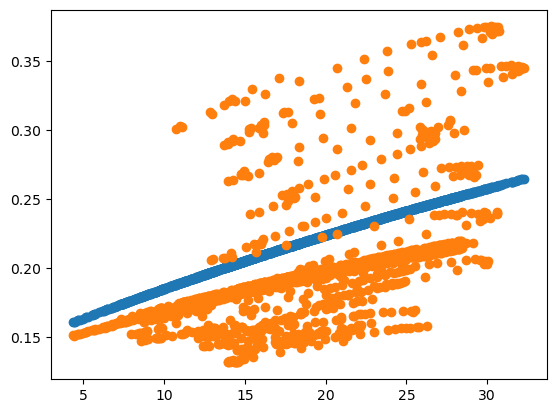

In [78]:
plt.scatter(cpk.loc[start:end, "TA"], falge_part.loc[start:end, "Reco"])
plt.scatter(cpk.loc[start:end, "TA"], reich_part.loc[start:end, "Reco"])


In [67]:
reich_diag.E0_diag

,idx,success,status,fun,R_ref,E0,nit,nfev,npoints,trange
0,2008-07-31,True,0,85.532942,0.200113,163.814909,116,219,242,16.508999
1,2008-08-14,True,0,100.623839,0.184853,4.443196,123,242,306,20.535000
2,2008-08-28,True,0,24.652967,0.171160,0.000000,62,115,87,15.661000
